In [3]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [5]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("/content/House Price Prediction Dataset.csv")
df.head(10)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
5,6,3944,1,2,1,1906,Urban,Poor,No,93262
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375


In [6]:
df.dtypes

,0
Id,int64
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
YearBuilt,int64
Location,object
Condition,object
Garage,object
Price,int64


In [8]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')

df.dtypes

,0
Id,int64
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
YearBuilt,int64
Location,object
Condition,object
Garage,object
Price,int64


In [9]:
df.isna().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [12]:
df_missing = df.copy()
df_missing.loc[0:5, 'Price'] = np.nan
df_missing.isna().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,6


In [13]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (2000, 10)
After removing some values:  (2000, 10)


In [14]:
df_missing.head(10)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,NaN
1,2,4272,5,4,3,1958,Downtown,Excellent,No,NaN
2,3,3592,2,2,3,1938,Downtown,Good,No,NaN
3,4,966,4,2,2,1902,Suburban,Fair,Yes,NaN
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,NaN
5,6,3944,1,2,1,1906,Urban,Poor,No,NaN
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722.0
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893.0
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878.0
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375.0


In [15]:
df_removed = df_missing.dropna()
df_removed.shape

(1994, 10)

In [16]:
df_removed.isna().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [24]:
df_imputed_mean = df_missing.copy()
df_imputed_mean['Price'].fillna(df_imputed_mean['Price'].mean(), inplace=True)

df_imputed_mean.isna().sum()

/tmp/ipython-input-1310457215.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_mean['Price'].fillna(df_imputed_mean['Price'].mean(), inplace=True)


,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [25]:
df_imputed_mean.head(10)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,538384.508024
1,2,4272,5,4,3,1958,Downtown,Excellent,No,538384.508024
2,3,3592,2,2,3,1938,Downtown,Good,No,538384.508024
3,4,966,4,2,2,1902,Suburban,Fair,Yes,538384.508024
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,538384.508024
5,6,3944,1,2,1,1906,Urban,Poor,No,538384.508024
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722.000000
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893.000000
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878.000000
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375.000000


In [26]:
df_imputed_median = df_missing.copy()
df_imputed_median['Price'].fillna(df_imputed_median['Price'].median(), inplace=True)

df_imputed_median.isna().sum()

/tmp/ipython-input-1945399632.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_median['Price'].fillna(df_imputed_median['Price'].median(), inplace=True)


,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [27]:
df_imputed_median.head(10)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,539965.0
1,2,4272,5,4,3,1958,Downtown,Excellent,No,539965.0
2,3,3592,2,2,3,1938,Downtown,Good,No,539965.0
3,4,966,4,2,2,1902,Suburban,Fair,Yes,539965.0
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,539965.0
5,6,3944,1,2,1,1906,Urban,Poor,No,539965.0
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722.0
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893.0
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878.0
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375.0


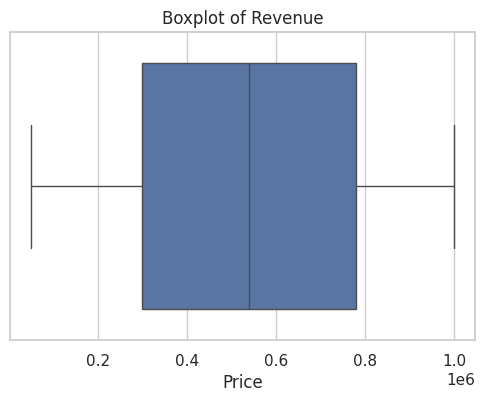

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of Revenue")
plt.show()

In [34]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]
outliers.head(15)
print("Total outliers found:", len(outliers))

Total outliers found: 0


In [37]:
#Note: There is no outliers in the code, but for studdying purpose
df_no_outliers = df[(df['Price'] >= lower) & (df['Price'] <= upper)]
print("Original shape: ",df.shape)
print("After removing outliers: ",df_no_outliers.shape)

lower_cap = df['Price'].quantile(0.05)
upper_cap = df['Price'].quantile(0.95)

df_capped = df.copy()
df_capped['Price'] = df_capped['Price'].clip(lower_cap, upper_cap)

Original shape:  (2000, 10)
After removing outliers:  (2000, 10)


In [38]:
df[['Area', 'Price']].head()

,Area,Price
0,1360,149919
1,4272,424998
2,3592,266746
3,966,244020
4,4926,636056


In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Area', 'Price']].copy()

df_scaled[['Area', 'Price']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Area,Price
0,0.190974,0.105211
1,0.838373,0.394875
2,0.687194,0.228232
3,0.103379,0.204301
4,0.983771,0.617123


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['Area', 'Price']].copy()

df_standardized[['Area', 'Price']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Area,Price
0,-1.101471,-1.403091
1,1.147485,-0.407725
2,0.622317,-0.980356
3,-1.405759,-1.062589
4,1.652574,0.355982


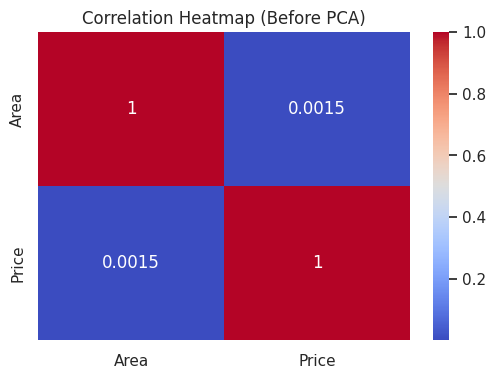

In [42]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Area','Price']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [43]:
from sklearn.decomposition import PCA

X = df_standardized[['Area', 'Price']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.50077106 0.49922894]


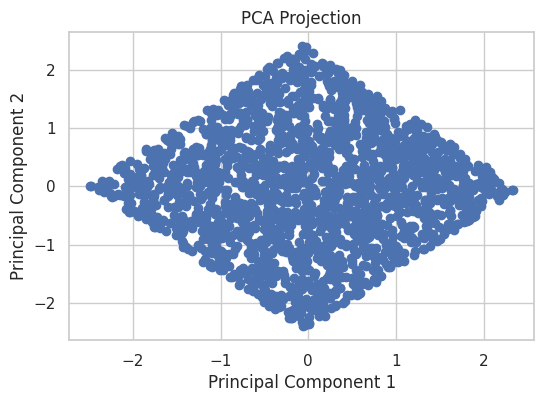

In [44]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()